<a href="https://colab.research.google.com/github/jenika14/Task-2-EDA/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Objective:
To perform Exploratory Data Analysis (EDA) on the diabetes dataset and identify key factors influencing diabetes.

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


1.Does glucose level affect diabetes?

2.Is BMI related to diabetes?

3.Which features strongly influence diabetes outcome?

4.Are there any outliers or missing values?

In [ ]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

Observations:

- The dataset contains medical attributes like Glucose, BMI, Age, etc.
- Some columns contain zero values which are not realistic (e.g., Glucose, BMI, BloodPressure).
- These zero values indicate missing data and need to be handled.
- The target variable 'Outcome' represents whether a person has diabetes (1) or not (0).

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [ ]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols]=df[cols].replace(0,np.nan)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)

Text(0, 0.5, 'Frequency')

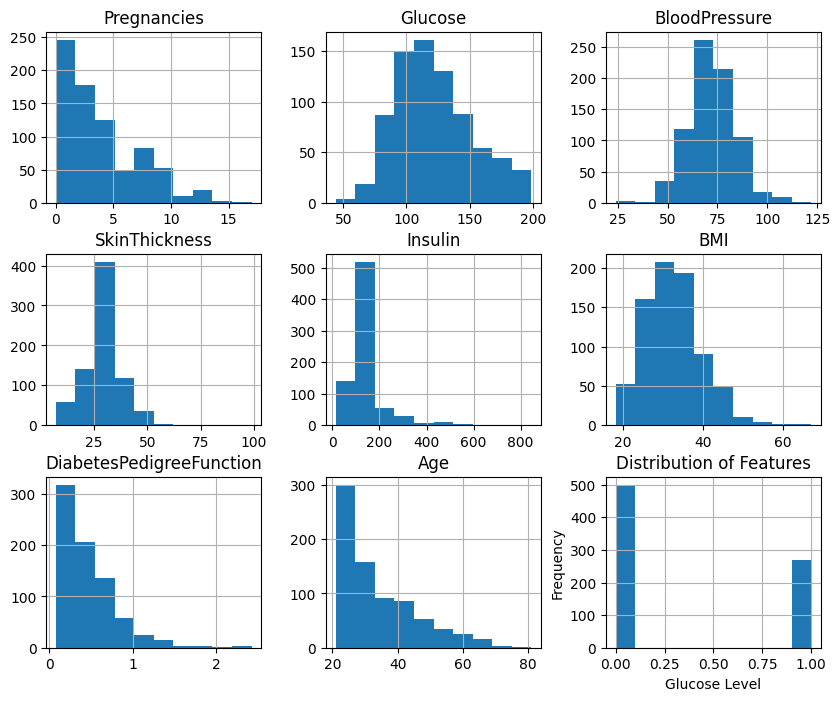

In [ ]:
df.hist(figsize=(10,8))
plt.title("Distribution of Features")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

Observation (Distribution):

- Most features are not normally distributed.
- Glucose and BMI show slight skewness.
- This indicates variation in patient health conditions.

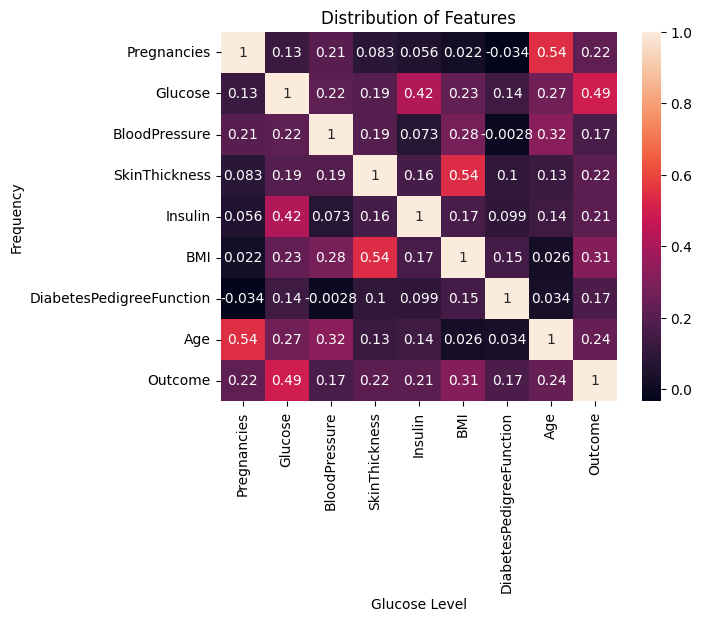

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.title("Distribution of Features")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

Correlation Insights:

- Glucose has the highest positive correlation with Outcome.
- BMI and Age also show moderate correlation.
- Other features have weaker relationships with diabetes.

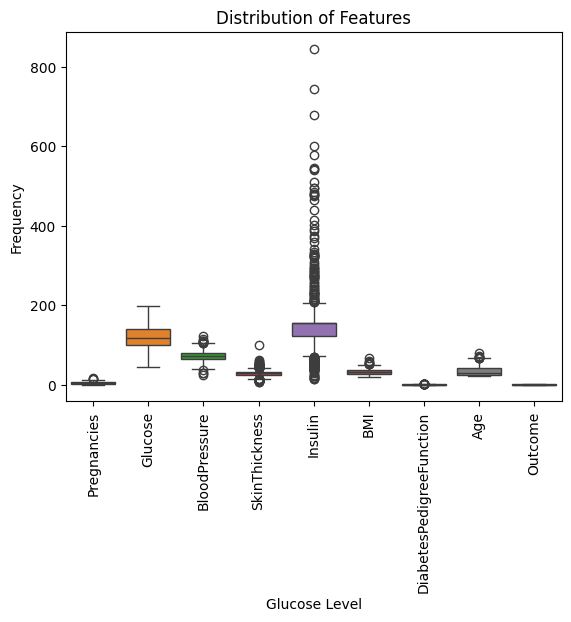

In [ ]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Features")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

Outlier Analysis

- Several features contain outliers, especially Glucose, BMI, and Insulin.
- Outliers may represent extreme medical conditions or data entry errors.
- These should be considered carefully in further modeling.

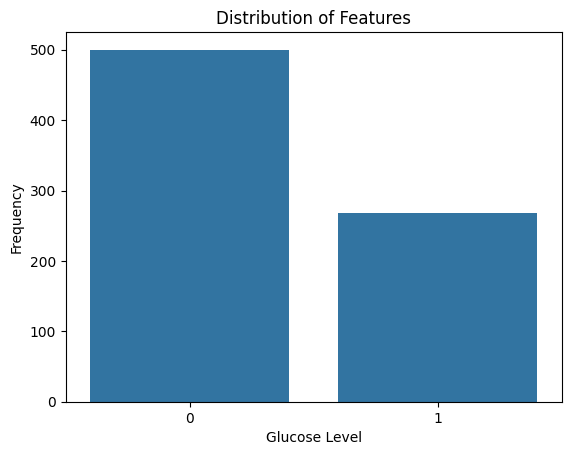

In [ ]:
sns.countplot(x='Outcome',data=df)
plt.title("Distribution of Features")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

Class Distribution:

- The dataset is slightly imbalanced.
- Number of non-diabetic cases is higher than diabetic cases.
- However, imbalance is not severe.

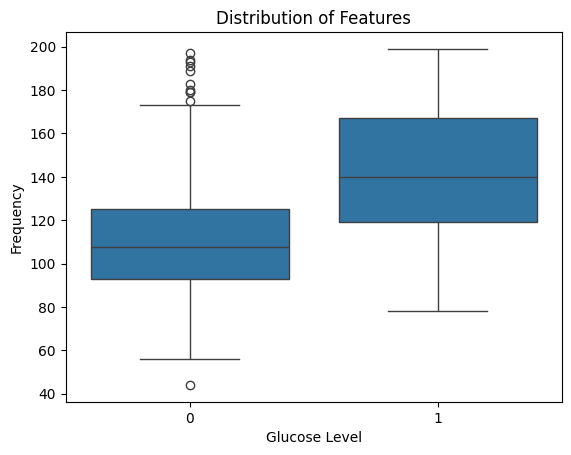

In [ ]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Distribution of Features")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

Key insight:

- People with higher glucose levels are more likely to have diabetes.
- This suggests glucose is a strong predictor of diabetes.

Hypothesis Testing:

**Hypothesis:** Higher glucose levels increase the chances of diabetes.

**Validation:**
- From the visualizations, diabetic patients tend to have higher glucose levels.
- This supports the hypothesis that glucose is a key factor in predicting diabetes.

Conclusion

- Glucose is the most important feature affecting diabetes.
- BMI and Age also play a significant role.
- Data cleaning was necessary due to missing/invalid values.
- The dataset shows meaningful patterns that can be used for prediction.
- EDA helped uncover trends, relationships, and potential issues in the dataset.
This analysis can be used as a foundation for building a machine learning model to predict diabetes.

Future Scope

- This dataset can be used to build a machine learning model to predict diabetes with high accuracy.